# Requirements

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Add as many imports as you need.

# Laboratory Exercise - Run Mode (8 points)

## Introduction
In this laboratory assignment, the focus is on time series forecasting, specifically targeting the prediction of the current **mean temperature** in the city of Delhi. Your task involves employing bagging and boosting methods to forecast the **mean temperature**. To accomplish this use data from the preceding three days, consisting of **mean temperature**, **humidity**, **wind speed**, and **mean pressure**.

**Note: You are required to perform this laboratory assignment on your local machine.**

## The Climate Dataset

## Downloading the Climate Dataset

In [4]:
#!gdown 1kczX2FpFTH1QEsDeg6dszXM3Azwyd7XC # Download the dataset.

## Exploring the Climate Dataset
This dataset consists of daily weather records for the city of Delhi spanning a period of 4 years (from 2013 to 2017). The dataset includes the following attributes:

- date - date in the format YYYY-MM-DD,
- meantemp - mean temperature averaged from multiple 3-hour intervals in a day,
- humidity - humidity value for the day (measured in grams of water vapor per cubic meter volume of air),
- wind_speed - wind speed measured in kilometers per hour, and
- meanpressure - pressure reading of the weather (measured in atm).

*Note: The dataset is complete, with no missing values in any of its entries.*

Load the dataset into a `pandas` data frame.

In [5]:
# Write your code here. Add as many boxes as you need.

In [6]:
import pandas as pd
data = pd.read_csv('climate-data.csv')

In [7]:
data.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


Explore the dataset using visualizations of your choice.

In [9]:
# Write your code here. Add as many boxes as you need.

In [10]:
data['date']

0       2013-01-01
1       2013-01-02
2       2013-01-03
3       2013-01-04
4       2013-01-05
           ...    
1457    2016-12-28
1458    2016-12-29
1459    2016-12-30
1460    2016-12-31
1461    2017-01-01
Name: date, Length: 1462, dtype: object

In [11]:
data_copy = data.copy()

In [12]:
data_copy['date'] = pd.to_datetime(data['date'])

In [13]:
data_copy = data_copy.set_index('date')

In [14]:
data_copy = data_copy.sort_index()

In [15]:
data_copy

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000
...,...,...,...,...
2016-12-28,17.217391,68.043478,3.547826,1015.565217
2016-12-29,15.238095,87.857143,6.000000,1016.904762
2016-12-30,14.095238,89.666667,6.266667,1017.904762


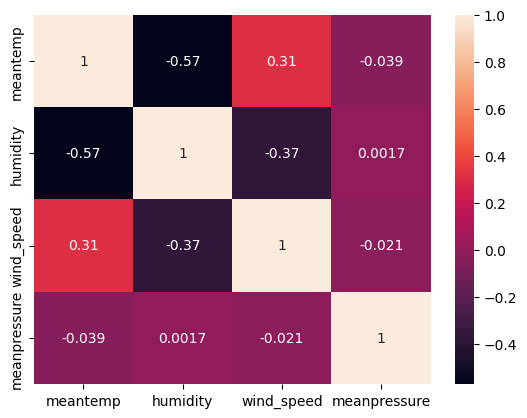

In [16]:
sns.heatmap(data_copy.corr(), annot=True)
plt.show()

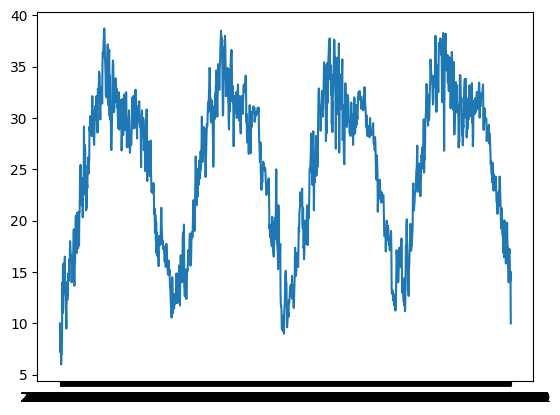

In [17]:
plt.plot(data['date'], data_copy['meantemp'])
plt.show()

# Feauture Extraction
Apply a lag of one, two, and three days to each feature, creating a set of features representing the meteorological conditions from the previous three days. To maintain dataset integrity, eliminate any resulting missing values at the beginning of the dataset.

Hint: Use `df['column_name'].shift(period)`. Check the documentation at https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html.

In [18]:
# Write your code here. Add as many boxes as you need.

In [19]:
lag = 3
for i in range(1, lag + 1):
    data_copy[f'meantemp_prev_{i}'] = data_copy['meantemp'].shift(i)
    data_copy[f'humidity_prev_{i}'] = data_copy['humidity'].shift(i)
    data_copy[f'wind_speed_prev_{i}'] = data_copy['wind_speed'].shift(i)
    data_copy[f'meanpressure_prev_{i}'] = data_copy['meanpressure'].shift(i)

In [20]:
data_copy = data_copy.dropna(axis=0)

In [21]:
data_copy

,meantemp,humidity,wind_speed,meanpressure,meantemp_prev_1,humidity_prev_1,wind_speed_prev_1,meanpressure_prev_1,meantemp_prev_2,humidity_prev_2,wind_speed_prev_2,meanpressure_prev_2,meantemp_prev_3,humidity_prev_3,wind_speed_prev_3,meanpressure_prev_3
date,,,,,,,,,,,,,,,,
2013-01-04,8.666667,71.333333,1.233333,1017.166667,7.166667,87.000000,4.633333,1018.666667,7.400000,92.000000,2.980000,1017.800000,10.000000,84.500000,0.000000,1015.666667
2013-01-05,6.000000,86.833333,3.700000,1016.500000,8.666667,71.333333,1.233333,1017.166667,7.166667,87.000000,4.633333,1018.666667,7.400000,92.000000,2.980000,1017.800000
2013-01-06,7.000000,82.800000,1.480000,1018.000000,6.000000,86.833333,3.700000,1016.500000,8.666667,71.333333,1.233333,1017.166667,7.166667,87.000000,4.633333,1018.666667
2013-01-07,7.000000,78.600000,6.300000,1020.000000,7.000000,82.800000,1.480000,1018.000000,6.000000,86.833333,3.700000,1016.500000,8.666667,71.333333,1.233333,1017.166667
2013-01-08,8.857143,63.714286,7.142857,1018.714286,7.000000,78.600000,6.300000,1020.000000,7.000000,82.800000,1.480000,1018.000000,6.000000,86.833333,3.700000,1016.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-28,17.217391,68.043478,3.547826,1015.565217,16.850000,67.550000,8.335000,1017.200000,17.142857,74.857143,8.784211,1016.952381,14.000000,94.300000,9.085000,1014.350000
2016-12-29,15.238095,87.857143,6.000000,1016.904762,17.217391,68.043478,3.547826,1015.565217,16.850000,67.550000,8.335000,1017.200000,17.142857,74.857143,8.784211,1016.952381
2016-12-30,14.095238,89.666667,6.266667,1017.904762,15.238095,87.857143,6.000000,1016.904762,17.217391,68.043478,3.547826,1015.565217,16.850000,67.550000,8.335000,1017.200000


## Dataset Splitting
Partition the dataset into training and testing sets with an 80:20 ratio.

**WARNING: DO NOT SHUFFLE THE DATASET.**



In [22]:
# Write your code here. Add as many boxes as you need.

In [23]:
features=['meantemp_prev_1', 'humidity_prev_1', 'wind_speed_prev_1', 'meanpressure_prev_1', 'meantemp_prev_2', 'humidity_prev_2', 'wind_speed_prev_2', 'meanpressure_prev_2', 'meantemp_prev_3', 'humidity_prev_3', 'wind_speed_prev_3', 'meanpressure_prev_3']

In [24]:
features

['meantemp_prev_1',
 'humidity_prev_1',
 'wind_speed_prev_1',
 'meanpressure_prev_1',
 'meantemp_prev_2',
 'humidity_prev_2',
 'wind_speed_prev_2',
 'meanpressure_prev_2',
 'meantemp_prev_3',
 'humidity_prev_3',
 'wind_speed_prev_3',
 'meanpressure_prev_3']

In [25]:
X = data_copy[features]
Y = data_copy['meantemp']

In [26]:
X

,meantemp_prev_1,humidity_prev_1,wind_speed_prev_1,meanpressure_prev_1,meantemp_prev_2,humidity_prev_2,wind_speed_prev_2,meanpressure_prev_2,meantemp_prev_3,humidity_prev_3,wind_speed_prev_3,meanpressure_prev_3
date,,,,,,,,,,,,
2013-01-04,7.166667,87.000000,4.633333,1018.666667,7.400000,92.000000,2.980000,1017.800000,10.000000,84.500000,0.000000,1015.666667
2013-01-05,8.666667,71.333333,1.233333,1017.166667,7.166667,87.000000,4.633333,1018.666667,7.400000,92.000000,2.980000,1017.800000
2013-01-06,6.000000,86.833333,3.700000,1016.500000,8.666667,71.333333,1.233333,1017.166667,7.166667,87.000000,4.633333,1018.666667
2013-01-07,7.000000,82.800000,1.480000,1018.000000,6.000000,86.833333,3.700000,1016.500000,8.666667,71.333333,1.233333,1017.166667
2013-01-08,7.000000,78.600000,6.300000,1020.000000,7.000000,82.800000,1.480000,1018.000000,6.000000,86.833333,3.700000,1016.500000
...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-28,16.850000,67.550000,8.335000,1017.200000,17.142857,74.857143,8.784211,1016.952381,14.000000,94.300000,9.085000,1014.350000
2016-12-29,17.217391,68.043478,3.547826,1015.565217,16.850000,67.550000,8.335000,1017.200000,17.142857,74.857143,8.784211,1016.952381
2016-12-30,15.238095,87.857143,6.000000,1016.904762,17.217391,68.043478,3.547826,1015.565217,16.850000,67.550000,8.335000,1017.200000


In [27]:
Y

date
2013-01-04     8.666667
2013-01-05     6.000000
2013-01-06     7.000000
2013-01-07     7.000000
2013-01-08     8.857143
                ...    
2016-12-28    17.217391
2016-12-29    15.238095
2016-12-30    14.095238
2016-12-31    15.052632
2017-01-01    10.000000
Name: meantemp, Length: 1459, dtype: float64

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,shuffle=False)

## Ensemble Learning Methods

### Bagging

Create an instance of a Random Forest model and train it using the `fit` function.

In [30]:
# Write your code here. Add as many boxes as you need.

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [32]:
random_forest_regressor = RandomForestRegressor()
random_forest_regressor.fit(x_train,y_train)

RandomForestRegressor()

Use the trained model to make predictions for the test set.

In [33]:
forest_regressor_predict = random_forest_regressor.predict(x_test)

Assess the performance of the model by using different metrics provided by the `scikit-learn` library.

In [34]:
print("Regression Report:")
mse = mean_squared_error(y_test, forest_regressor_predict) 
r2 = r2_score(y_test, forest_regressor_predict)
print(f"Mean Square Error: {mse}")
print(f"R2 Score: {r2}")

Regression Report:
Mean Square Error: 3.081384701866513
R2 Score: 0.9038015011766949


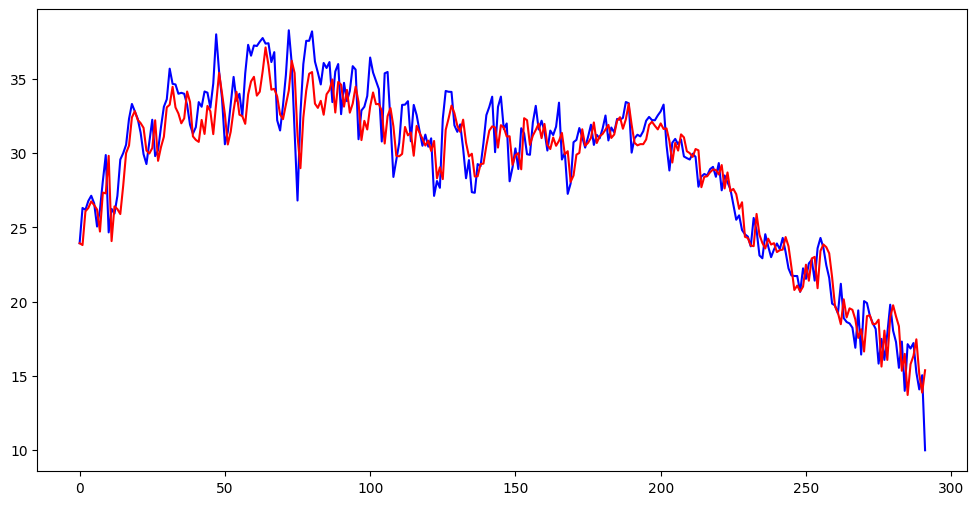

In [35]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, color='blue')
plt.plot(forest_regressor_predict, color='red')
plt.show()

### Boosting

Create an instance of an XGBoost model and train it using the `fit` function.

In [36]:
from xgboost import XGBRegressor

In [37]:
xgb_regressor = XGBRegressor()
xgb_regressor.fit(x_train,y_train)

D:\Miniconda\envs\env2\lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The XGBRegressor or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

Use the trained model to make predictions for the test set.

In [38]:
xgb_regressor_predict = xgb_regressor.predict(x_test)

Assess the performance of the model by using different metrics provided by the `scikit-learn` library.

In [39]:
# Write your code here. Add as many boxes as you need.

In [40]:
print("Regression Report:")
mse = mean_squared_error(y_test, xgb_regressor_predict) 
r2 = r2_score(y_test, xgb_regressor_predict)
print(f"Mean Square Error: {mse}")
print(f"R2 Score: {r2}")

Regression Report:
Mean Square Error: 4.061991489304081
R2 Score: 0.873187699261505


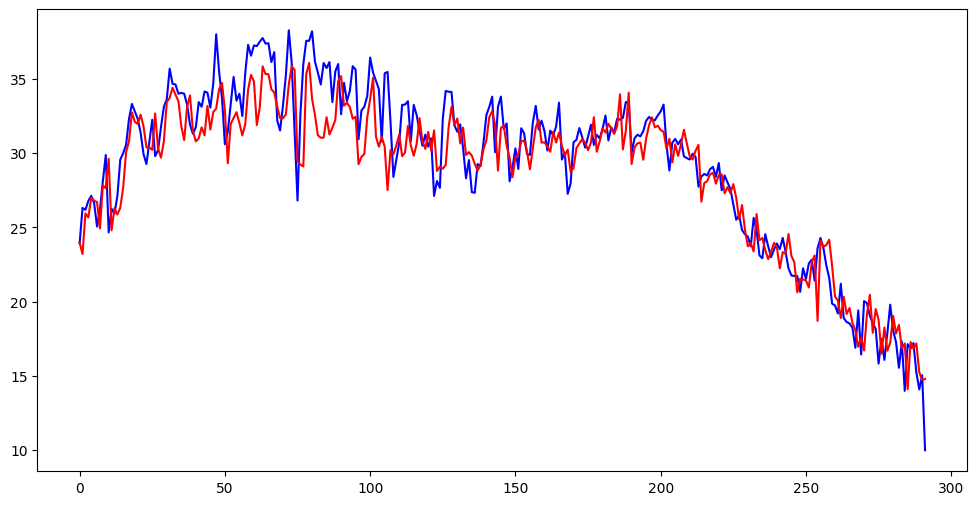

In [41]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, color='blue')
plt.plot(xgb_regressor_predict, color='red')
plt.show()

# Laboratory Exercise - Bonus Task (+ 2 points)

Define the forecasting model using the **Keras Sequential API** (`keras.models.Sequential`), incorporating one or more LSTM layers along with additional relevant layers (`keras.layers`). Be cautious when specifying the configuration of the final layer to ensure proper model output for the forecasting task.

In [42]:
!pip install tensorflow

In [43]:
!pip install keras

In [44]:
!pip install tensorflow

In [45]:
import keras

In [50]:
from keras.layers import Dense
from keras.models import Sequential

model = Sequential()

model.add(Dense(64, input_dim=12, activation='relu'))

model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))

model.add(Dense(1,activation='linear'))

D:\Miniconda\envs\env2\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
model.compile(loss=keras.losses.MeanSquaredError() , optimizer=keras.optimizers.Adam(), metrics=[keras.metrics.MeanSquaredError(), keras.metrics.MeanAbsoluteError() ])

In [52]:
history = model.fit(x_train, y_train, batch_size=16, validation_split=0.2, epochs=20, shuffle=False)

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 1333.6354 - mean_absolute_error: 28.2698 - mean_squared_error: 1333.6354 - val_loss: 202.4125 - val_mean_absolute_error: 12.4570 - val_mean_squared_error: 202.4125
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 223.2251 - mean_absolute_error: 12.1261 - mean_squared_error: 223.2251 - val_loss: 148.6951 - val_mean_absolute_error: 10.3132 - val_mean_squared_error: 148.6951
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 164.3066 - mean_absolute_error: 10.4472 - mean_squared_error: 164.3066 - val_loss: 135.8052 - val_mean_absolute_error: 9.7472 - val_mean_squared_error: 135.8052
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 146.9278 - mean_absolute_error: 9.8387 - mean_squared_error: 146.9278 - val_loss: 128.8780 - val_mean_absolute_error: 9.4388 - val_mean_squared_error: 128.8780
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 131.1408 - mean_absolute_error: 9.1762 - mean_squared_error: 1

In [53]:
y_pred = model.predict(x_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [54]:
print("Regression Report:")
mse = mean_squared_error(y_test, y_pred) 
r2 = r2_score(y_test, y_pred)
print(f"Mean Square Error: {mse}")
print(f"R2 Score: {r2}")

Regression Report:
Mean Square Error: 272.7608955934275
R2 Score: -7.515388772422318
